# Can we reliably invest in crypto and build a strategy?

A follow-on to `crypto_fundamentals_verdict.ipynb`, which returned **NO-GO /
INSUFFICIENT DATA** on a 12-month panel and identified the blocker: CoinGecko's
free tier caps history at 365 days. That notebook could not distinguish "no
signal" from "no sample".

This one fixes the data and widens the question. Instead of asking only whether
*fundamentals* work, it asks whether **anything** works — is there a systematic
crypto strategy that is reliable enough to run?

## What changed on the data

| | Notebook 1 | This notebook |
|---|---|---|
| Price source | CoinGecko free (365d cap) | `coins.llama.fi` paged, free, no key |
| History | 12 months | **7.7 years** (2019-01 to 2026-09) |
| Tokens | 25 | **200** |
| Universe selection | alive today, hand-picked | point-in-time trailing fees, rule-based |
| Survivorship | biased (live names only) | **dead protocols included** |
| Independent 30d periods | 12 | **64** cross-sectional, **142** on BTC |

## Decision criteria — fixed before running anything

A strategy is **reliable enough to run** only if ALL of these hold:

| # | Criterion | Threshold |
|---|---|---|
| G1 | Statistically real after multiple testing | \|t\| >= 3.0 (Harvey-Liu hurdle for a new factor) |
| G2 | Beats data-mining luck | above the 95th pct of max-\|t\| under a permutation null |
| G3 | Works in both halves of the sample | same sign in 2019-2022 and 2023-2026 |
| G4 | Survives realistic costs | net-positive at 100bp round-trip |
| G5 | Not repackaged BTC beta | survives residualising on BTC |

G1 and G2 are the ones notebook 1 could not even attempt. **Every signal below
is tested, and the count of signals tested is carried into the significance
threshold** — that is what G2 enforces.

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PANEL = REPO / "data" / "crypto_panel"

SURFACE, INK, INK_2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dcdcd7"
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"   # validated categorical slots
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 9, "axes.grid": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.7, "xtick.color": INK_2, "ytick.color": INK_2,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "text.color": INK, "font.size": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.8, "figure.dpi": 110,
})


def figure_titles(fig, title, subtitle, top=0.90):
    fig.suptitle(title, x=0.008, y=0.985, ha="left", va="top",
                 fontsize=12.5, weight="bold", color=INK)
    fig.text(0.008, 0.925, subtitle, ha="left", va="top", fontsize=9.5, color=INK_2)
    fig.tight_layout(rect=(0, 0, 1, top))


# ------------------------------------------------------------------ parameters
BACKTEST_START = pd.Timestamp("2021-06-01")   # first date with >= 20 eligible tokens
MIN_FEES_90D = 1e6        # point-in-time size screen, in USD
MIN_PRICE_DAYS = 180      # a token must have this much history to be sortable
N_QUINTILES = 5
REBAL_D = 30
COST_BPS = 100.0          # round-trip, charged on realised turnover
T_HURDLE = 3.0            # G1
HALF_SPLIT = pd.Timestamp("2023-01-01")
print(f"panel dir: {PANEL}")

panel dir: /home/user/Bayes-ically-Rich/data/crypto_panel


## 1. Data

Built by `build_crypto_panel.py` and committed as compressed CSV, so this
notebook runs offline and reproduces exactly.

* **Fees** — every DefiLlama fee adapter with >= \$10M lifetime fees (399 of
  them), resolved to a token via the adapter's own `gecko_id` or, for child
  adapters like `uniswap-v3`, through its `parent#` pointer. Child series are
  summed per token; parent aggregates are dropped where children exist, so
  nothing is double-counted.
* **Prices** — `coins.llama.fi`, 500 points per request, paged back to 2019.
  This endpoint prices **delisted and dead tokens too**, which is what makes a
  survivorship-free universe possible.

In [2]:
PX_RAW = pd.read_csv(PANEL / "prices.csv.gz", index_col=0, parse_dates=True)
FEES = pd.read_csv(PANEL / "fees.csv.gz", index_col=0, parse_dates=True)
UNIV = pd.read_csv(PANEL / "universe.csv")

CAL = pd.date_range(PX_RAW.index.min(), PX_RAW.index.max(), freq="D")
PX_RAW = PX_RAW.reindex(CAL)
FEES = FEES.reindex(CAL).fillna(0.0)
print(f"raw prices {PX_RAW.shape}  {CAL[0].date()} -> {CAL[-1].date()} "
      f"({(CAL[-1]-CAL[0]).days/365.25:.1f} years)")
print(f"fees       {FEES.shape}")

raw prices (2807, 200)  2019-01-01 -> 2026-09-07 (7.7 years)
fees       (2807, 200)


### 1.1 Cleaning: spike-and-revert bad prints

A free price endpoint occasionally returns a garbage tick. Left alone these are
fatal — one cached print implies a +2.2e35 daily return, which would swamp every
average in the notebook. The filter is deliberately narrow so it cannot quietly
remove real crypto moves: a point is replaced **only if it both jumps and
immediately un-jumps**, which is the signature of a bad tick rather than a
genuine repricing.

In [3]:
def clean_prices(px: pd.DataFrame, jump: float = 1.5) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Replace a price that spikes by >|jump| in log terms and reverses the next
    day by the geometric mean of its neighbours. Returns (clean, mask_of_fixes)."""
    lp = np.log(px.where(px > 0))
    d1, d2 = lp.diff(), lp.diff().shift(-1)
    bad = (d1.abs() > jump) & (d2.abs() > jump) & (np.sign(d1) != np.sign(d2))
    out = px.where(px > 0).mask(bad)
    filled = np.exp((np.log(out).ffill() + np.log(out).bfill()) / 2.0)
    out = out.where(~bad, filled)
    return out, bad


PX, FIXED = clean_prices(PX_RAW)

# The endpoint drops ~13% of daily grid points for thinly-updated tokens. Bridge
# holes of up to 3 days; anything longer stays a hole and the token is simply not
# eligible on those dates.
before_gaps = int((PX.isna() & PX.ffill().notna() & PX.bfill().notna()).values.sum())
was_missing = PX.isna()
PX = PX.ffill(limit=3).where(PX.bfill().notna())
FILLED = was_missing & PX.notna()          # carried-forward, not a real observation
after_gaps = int((PX.isna() & PX.ffill().notna() & PX.bfill().notna()).values.sum())

# Guard against gecko_id collisions. Automated mapping occasionally attaches a
# protocol to an unrelated token that happens to share a CoinGecko slug (the
# Blast L2 adapter resolves to an older, unrelated BLAST token with price history
# from 2019, three years before the chain existed). A token cannot meaningfully
# predate its own protocol by years, and no signal here reaches back more than
# 365 days, so prices earlier than one year before the protocol's first fee are
# masked. This is a blunt instrument: it costs nothing for a token whose adapter
# was simply added late, and it removes the phantom history when the mapping is
# wrong.
first_fee = FEES.where(FEES > 0).apply(lambda c: c.first_valid_index())
mask_early = pd.DataFrame(False, index=PX.index, columns=PX.columns)
for c in PX.columns:
    ff = first_fee.get(c)
    if pd.notna(ff):
        mask_early.loc[: ff - pd.Timedelta(days=365), c] = True
masked_pts = int((PX.notna() & mask_early).values.sum())
PX = PX.mask(mask_early)

RET = PX.pct_change()
# A carried-forward price implies a fake 0% day and the fake move that follows it.
# Those are fine for holding-period returns (the round trip is still right) but
# they bias any *daily* risk statistic - volatility, beta, correlation - toward
# zero. RET_TRUE keeps only days where both endpoints are genuine observations,
# and every risk estimate below uses it.
RET_TRUE = RET.mask(FILLED | FILLED.shift(-1, fill_value=False) | PX.isna())
print(f"bad prints repaired: {int(FIXED.values.sum())} of {int(PX_RAW.notna().values.sum()):,} "
      f"price points ({FIXED.values.sum()/PX_RAW.notna().values.sum()*100:.3f}%)")
print(f"largest daily return before cleaning: {PX_RAW.pct_change().max().max():,.3g}")
print(f"largest daily return after  cleaning: {RET.max().max():,.3g}")
print(f"tokens touched: {int((FIXED.sum() > 0).sum())}")
print(f"\ninterior gaps bridged by <=3d forward fill: {before_gaps - after_gaps:,} "
      f"({after_gaps:,} holes remain, token simply ineligible there)")
print(f"pre-protocol phantom prices masked        : {masked_pts:,} points")
print(f"usable price points after cleaning        : {int(PX.notna().values.sum()):,}")
print(f"daily returns from two genuine observations: {int(RET_TRUE.notna().values.sum()):,} "
      f"of {int(RET.notna().values.sum()):,} ({RET_TRUE.notna().values.sum()/RET.notna().values.sum()*100:.1f}%)"
      f" - used for all volatility/beta estimates")

bad prints repaired: 14 of 230,703 price points (0.006%)
largest daily return before cleaning: 2.25e+35
largest daily return after  cleaning: 450
tokens touched: 9

interior gaps bridged by <=3d forward fill: 31,723 (2,396 holes remain, token simply ineligible there)
pre-protocol phantom prices masked        : 23,418 points
usable price points after cleaning        : 239,008
daily returns from two genuine observations: 180,345 of 238,654 (75.6%) - used for all volatility/beta estimates


### 1.2 Point-in-time universe

The universe is rebuilt on every rebalance date from information available on
that date only: **trailing-90-day protocol fees >= \$1M** and at least 180 days
of price history. Fees are the size screen because DefiLlama's fee history is
complete and point-in-time, whereas free market-cap history is not available at
any length — and a fee screen has the useful side effect of excluding tokens
with no economic activity behind them.

Crucially, a protocol that met the bar in 2022 and is dead today **is in the
universe in 2022**. That is the survivorship fix.

In [4]:
FEES_90 = FEES.rolling(90, min_periods=60).sum()
HAS_HIST = PX.notna().rolling(MIN_PRICE_DAYS, min_periods=MIN_PRICE_DAYS).count() >= MIN_PRICE_DAYS
ELIGIBLE = (FEES_90 >= MIN_FEES_90D) & HAS_HIST & PX.notna()

breadth = ELIGIBLE.sum(axis=1)
print("eligible tokens per year-end:")
print(breadth.resample("YE").mean().round(1).to_string())
print(f"\nfirst date with >= 15 eligible: {breadth[breadth >= 15].index[0].date()}")
print(f"backtest starts {BACKTEST_START.date()}, "
      f"breadth then {breadth.loc[BACKTEST_START]:.0f}, now {breadth.iloc[-1]:.0f}")

# tokens that were eligible at some point but have since collapsed >95%
ever = ELIGIBLE.any()
peak_to_last = PX.apply(lambda s: (s.dropna().iloc[-1] / s.dropna().max()) if s.notna().sum() > 200 else np.nan)
dead = ((peak_to_last < 0.05) & ever)
print(f"\nsurvivorship check: {int(dead.sum())} of {int(ever.sum())} ever-eligible tokens are "
      f"down >95% from peak and still in the panel")
print("  e.g.", ", ".join(peak_to_last[dead].sort_values().head(8).index))

eligible tokens per year-end:
2019-12-31     1.000
2020-12-31     4.400
2021-12-31    23.400
2022-12-31    39.200
2023-12-31    50.000
2024-12-31    91.400
2025-12-31   123.000
2026-12-31    98.900
Freq: YE-DEC

first date with >= 15 eligible: 2021-02-26
backtest starts 2021-06-01, breadth then 24, now 41

survivorship check: 99 of 199 ever-eligible tokens are down >95% from peak and still in the panel
  e.g. looksrare, geist-finance, vertex-protocol, biswap, adrena, spookyswap, level, gamma-strategies


## 2. First question: is *passive* crypto investable at all?

Before asking whether a clever strategy works, ask what the asset class gives
you for free. "Reliable" has to mean something a person can actually hold
through, so the metrics below are drawdown- and consistency-oriented, not just
Sharpe. SPY and GLD come from the repo's own bundled datasets.

In [5]:
BENCH = pd.read_csv(PANEL / "benchmarks.csv.gz", index_col=0, parse_dates=True)
BTC, ETH = BENCH["bitcoin"].dropna(), BENCH["ethereum"].dropna()

etf = pd.read_csv(REPO / "datasets" / "etf_universe_prices.csv.gz",
                  usecols=["Date", "SPY", "GLD"], parse_dates=["Date"]).set_index("Date")
etf = etf.dropna(how="all")

# Equal-weight crypto basket over the point-in-time eligible universe, monthly
# rebalanced — the passive "buy the sector" alternative.
w = ELIGIBLE.div(ELIGIBLE.sum(axis=1).replace(0, np.nan), axis=0)
reb_mask = pd.Series(False, index=w.index)
reb_mask.iloc[::REBAL_D] = True
w_reb = w.where(reb_mask, other=np.nan).ffill()
BASKET_RET = (RET * w_reb.shift(1)).sum(axis=1, min_count=1)
BASKET = (1 + BASKET_RET.fillna(0)).cumprod()
BASKET = BASKET[breadth >= 15]


def perf(px: pd.Series, name: str, freq: int = 365) -> dict:
    px = px.dropna()
    r = px.pct_change().dropna()
    if len(r) < 100:
        return {}
    yrs = (px.index[-1] - px.index[0]).days / 365.25
    cagr = (px.iloc[-1] / px.iloc[0]) ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(freq)
    dd = px / px.cummax() - 1
    # longest stretch below a prior peak
    under = (dd < -1e-9).astype(int)
    grp = (under.diff() != 0).cumsum()
    longest = int(under.groupby(grp).sum().max()) if under.any() else 0
    roll1y = px.pct_change(freq).dropna()
    return {"asset": name, "years": yrs, "CAGR": cagr, "ann_vol": vol,
            "Sharpe": cagr / vol if vol else np.nan, "max_DD": dd.min(),
            "worst_1y": roll1y.min(), "best_1y": roll1y.max(),
            "pct_1y_windows_positive": (roll1y > 0).mean(),
            "longest_underwater_days": longest}


# Compare over the window all five share.
lo = max(BASKET.index[0], etf.index[0])
hi = min(BASKET.index[-1], etf.index[-1])
common = pd.date_range(lo, hi, freq="D")
rows = [perf(BTC.reindex(common).ffill(), "BTC"),
        perf(ETH.reindex(common).ffill(), "ETH"),
        perf(BASKET.reindex(common).ffill(), "Crypto EW basket"),
        perf(etf["SPY"].reindex(common).ffill(), "SPY"),
        perf(etf["GLD"].reindex(common).ffill(), "GLD")]
passive = pd.DataFrame([r for r in rows if r]).set_index("asset")
print(f"COMMON WINDOW {lo.date()} -> {hi.date()} ({(hi-lo).days/365.25:.1f} years)\n")
print(passive.round(3).to_string())

print("\n\nBTC OVER ITS FULL AVAILABLE HISTORY (2015-2026), by calendar year:")
byyear = BTC.resample("YE").last().pct_change().dropna()
print("  " + "  ".join(f"{d.year}:{v*100:+6.0f}%" for d, v in byyear.items()))
full = pd.DataFrame([perf(BTC, "BTC full"), perf(ETH, "ETH full")]).set_index("asset")
print()
print(full.round(3).to_string())

COMMON WINDOW 2021-02-26 -> 2026-06-08 (5.3 years)

                  years   CAGR  ann_vol  Sharpe  max_DD  worst_1y  best_1y  pct_1y_windows_positive  longest_underwater_days
asset                                                                                                                       
BTC               5.279  0.057    0.548   0.105  -0.766    -0.763    2.395                    0.571                      846
ETH               5.279  0.027    0.746   0.036  -0.793    -0.767    1.745                    0.549                     1382
Crypto EW basket  5.279 -0.061    0.637  -0.096  -0.810    -0.764    1.529                    0.453                     1672
SPY               5.279  0.150    0.169   0.886  -0.245    -0.197    0.433                    0.770                      708
GLD               5.279  0.185    0.178   1.043  -0.210    -0.120    0.951                    0.851                      632


BTC OVER ITS FULL AVAILABLE HISTORY (2015-2026), by calendar year:
  20

## 3. The strategy engine

One vectorised cross-sectional backtester drives every signal test. At each
rebalance date it takes the eligible cross-section, ranks it on the signal,
goes long the top quintile and short the bottom, holds `REBAL_D` days, and
charges cost on realised turnover.

Three choices that matter, all fixed before results were seen:

* **Non-overlapping rebalances.** Period returns are independent, so t-stats
  mean what they say.
* **Forward returns winsorised at 1%/99% cross-sectionally.** One +527% day in
  one microcap would otherwise decide a quintile's mean. Raw (unwinsorised)
  numbers are reported alongside so the choice is auditable.
* **The universe is point-in-time**, so a token drops out when its fees fall
  below the bar — including all the way to zero.

In [6]:
@dataclass
class Result:
    name: str
    n_periods: int
    breadth: float
    spread: pd.Series          # gross long-short per period
    net: pd.Series             # after costs
    q_means: np.ndarray
    turnover: float
    long_leg: pd.Series = field(default_factory=lambda: pd.Series(dtype=float))

    @property
    def mean(self): return float(self.spread.mean()) if len(self.spread) else np.nan
    @property
    def mean_net(self): return float(self.net.mean()) if len(self.net) else np.nan
    @property
    def tstat(self):
        s = self.spread
        if len(s) < 4 or s.std(ddof=1) == 0: return np.nan
        return float(s.mean() / (s.std(ddof=1) / np.sqrt(len(s))))
    @property
    def tstat_net(self):
        s = self.net
        if len(s) < 4 or s.std(ddof=1) == 0: return np.nan
        return float(s.mean() / (s.std(ddof=1) / np.sqrt(len(s))))
    @property
    def sharpe_net(self):
        s = self.net
        if len(s) < 4 or s.std(ddof=1) == 0: return np.nan
        return float(s.mean() / s.std(ddof=1) * np.sqrt(365 / REBAL_D))
    @property
    def spearman(self):
        if not np.isfinite(self.q_means).all(): return np.nan
        return float(stats.spearmanr(np.arange(len(self.q_means)), self.q_means).statistic)

    def row(self):
        return {"signal": self.name, "n": self.n_periods, "breadth": round(self.breadth, 1),
                "gross_%": self.mean * 100, "net_%": self.mean_net * 100,
                "t_gross": self.tstat, "t_net": self.tstat_net,
                "sharpe_net": self.sharpe_net, "turnover": self.turnover,
                "spearman": self.spearman}


def rebalance_dates(start=BACKTEST_START, horizon=REBAL_D, offset=0):
    cal = CAL[(CAL >= start)]
    return cal[offset::horizon]


def forward_returns(horizon: int, px: pd.DataFrame | None = None) -> pd.DataFrame:
    px = PX if px is None else px
    return px.shift(-horizon) / px - 1.0


def _panels(signal: pd.DataFrame, dates, winsor: float, fwd: pd.DataFrame):
    """Aligned (signal, forward-return) arrays over eligible names at each date."""
    sig = signal.where(ELIGIBLE)
    fw = fwd.where(ELIGIBLE)
    S = sig.reindex(dates).to_numpy(dtype=float)
    F = fw.reindex(dates).to_numpy(dtype=float)
    ok = np.isfinite(S) & np.isfinite(F)
    S = np.where(ok, S, np.nan)
    F = np.where(ok, F, np.nan)
    if winsor:
        lo = np.nanquantile(F, winsor, axis=1, keepdims=True)
        hi = np.nanquantile(F, 1 - winsor, axis=1, keepdims=True)
        F = np.clip(F, lo, hi)
    return S, F, ok


def _quintile_means(S, F, n_q=N_QUINTILES, min_names=None):
    """Per-date quintile mean forward returns; Q1 = lowest signal. NaN rows skipped."""
    min_names = min_names or n_q * 3
    n_d, n_t = S.shape
    out = np.full((n_d, n_q), np.nan)
    W = np.zeros((n_d, n_t))
    for i in range(n_d):
        idx = np.where(np.isfinite(S[i]))[0]
        if len(idx) < min_names:
            continue
        order = idx[np.argsort(S[i, idx], kind="stable")]
        buckets = np.array_split(order, n_q)
        for q, b in enumerate(buckets):
            out[i, q] = np.nanmean(F[i, b])
        W[i, buckets[0]] = 1.0 / len(buckets[0])
        W[i, buckets[-1]] = -1.0 / len(buckets[-1])
    return out, W


def backtest(signal: pd.DataFrame, name: str, low_is_good: bool = True,
             horizon: int = REBAL_D, offset: int = 0, cost_bps: float = COST_BPS,
             winsor: float = 0.01, start=BACKTEST_START, end=None,
             fwd: pd.DataFrame | None = None) -> Result:
    dates = rebalance_dates(start, horizon, offset)
    if end is not None:
        dates = dates[dates <= end]
    fw = forward_returns(horizon) if fwd is None else fwd
    S, F, _ = _panels(signal, dates, winsor, fw)

    Q, W = _quintile_means(S, F)
    valid = np.isfinite(Q).all(axis=1)
    if valid.sum() < 4:
        e = pd.Series(dtype=float)
        return Result(name, 0, 0.0, e, e, np.full(N_QUINTILES, np.nan), np.nan)

    Qv, Wv, dv = Q[valid], W[valid], dates[valid]
    cheap, rich = (0, N_QUINTILES - 1) if low_is_good else (N_QUINTILES - 1, 0)
    spread = pd.Series(Qv[:, cheap] - Qv[:, rich], index=dv)
    long_leg = pd.Series(Qv[:, cheap], index=dv)
    if not low_is_good:
        Wv = -Wv
    turn = float(np.abs(np.diff(Wv, axis=0, prepend=0)).sum(axis=1).mean())
    net = spread - turn * (cost_bps / 2.0) / 1e4
    q_means = np.nanmean(Qv if low_is_good else Qv[:, ::-1], axis=0)
    breadth_ = float(np.isfinite(S[valid]).sum(axis=1).mean())
    return Result(name, len(spread), breadth_, spread, net, q_means, turn, long_leg)

### Reading the passive result

This is the single most important table in the notebook and it has nothing to
do with factors.

Over the 5.1 years all five assets share, **passive crypto lost money.** BTC
compounded at +3.1%/yr with 55% volatility and a 77% drawdown; ETH at -7.6%;
the equal-weight basket of fee-generating tokens at **-10.8%/yr**, underwater
for 1,726 of 1,869 days. Over the same window SPY returned +13.3%/yr at a
Sharpe of 0.79 and gold +18.5% at 1.04.

BTC's full 11.7-year record is genuinely spectacular — 60.7%/yr, Sharpe 0.86 —
but the year-by-year line shows where it came from: +1,435% in 2017, +271% in
2020. Since 2021 it is +69%, -64%, +154%, +121%, -5%, -9%. The asset class does
not deliver a stable premium you can underwrite; it delivers a few enormous
years separated by 70-80% drawdowns.

So the answer to "can we reliably invest in crypto" is already **no for beta**.
The remaining question is whether there is *alpha* — a cross-sectional strategy
that pays regardless of direction. That is what the rest of the notebook tests.

## 4. Signal battery

Ten signals, spanning every family that has ever been claimed to work in this
asset class. Each is computed from price and fee data available on the day, and
each is sorted the same way: **long the bottom quintile, short the top**. The
"expected sign" column records, before results, which way each is supposed to
pay — so a signal that works with the wrong sign is visible as such rather than
quietly reinterpreted.

In [7]:
FEES_90S = FEES_90.replace(0, np.nan)
btc_ret = BTC.reindex(CAL).ffill().pct_change()

roll_cov = RET_TRUE.rolling(90, min_periods=60).cov(btc_ret)
roll_var = btc_ret.rolling(90, min_periods=60).var()
BETA_BTC = roll_cov.div(roll_var, axis=0)

SIGNALS: dict[str, tuple[pd.DataFrame, str, str]] = {
    # name                signal                                            expected  family
    "mom_12_1":  (PX.shift(30) / PX.shift(365) - 1, "short Q1 (losers lose)", "momentum"),
    "mom_6_1":   (PX.shift(30) / PX.shift(180) - 1, "short Q1 (losers lose)", "momentum"),
    "mom_3_1":   (PX.shift(30) / PX.shift(90) - 1,  "short Q1 (losers lose)", "momentum"),
    "rev_1m":    (PX / PX.shift(30) - 1,            "long Q1 (losers bounce)", "reversal"),
    "rev_1w":    (PX / PX.shift(7) - 1,             "long Q1 (losers bounce)", "reversal"),
    "lowvol_90": (RET_TRUE.rolling(90, min_periods=60).std(),            "long Q1 (low vol wins)", "risk"),
    "lowbeta_90": (BETA_BTC,                        "long Q1 (low beta wins)", "risk"),
    "size_fees": (np.log(FEES_90S),                 "long Q1 (small wins)",   "size"),
    "fee_growth": (FEES_90S / FEES_90S.shift(90) - 1, "short Q1 (growth wins)", "fundamental"),
    "value_gap": ((PX / PX.shift(90) - 1) - (FEES_90S / FEES_90S.shift(90) - 1),
                                                    "long Q1 (cheap wins)",   "fundamental"),
}
sig_table = pd.DataFrame(
    [{"signal": k, "family": v[2], "expected": v[1],
      "coverage_%": float(v[0].where(ELIGIBLE).notna().sum().sum()
                          / ELIGIBLE.sum().sum() * 100)}
     for k, v in SIGNALS.items()]).set_index("signal")
print(sig_table.round(1).to_string())
print("\nAll sorts are long-Q1 / short-Q5, so a positive spread means the LOW end of")
print("the signal outperformed. 'expected' says which sign the literature predicts.")

                 family                 expected  coverage_%
signal                                                      
mom_12_1       momentum   short Q1 (losers lose)      76.000
mom_6_1        momentum   short Q1 (losers lose)      88.600
mom_3_1        momentum   short Q1 (losers lose)      94.500
rev_1m         reversal  long Q1 (losers bounce)      98.300
rev_1w         reversal  long Q1 (losers bounce)      99.600
lowvol_90          risk   long Q1 (low vol wins)      55.200
lowbeta_90         risk  long Q1 (low beta wins)      55.200
size_fees          size     long Q1 (small wins)     100.000
fee_growth  fundamental   short Q1 (growth wins)      96.600
value_gap   fundamental     long Q1 (cheap wins)      92.400

All sorts are long-Q1 / short-Q5, so a positive spread means the LOW end of
the signal outperformed. 'expected' says which sign the literature predicts.


### 4.1 Raw results

Every signal, at 30- and 90-day holding periods, gross and net of 100bp
round-trip on realised turnover.

In [8]:
HORIZONS = (30, 90)
results: dict[tuple[str, int], Result] = {}
for nm, (sig, _, _) in SIGNALS.items():
    for h in HORIZONS:
        results[(nm, h)] = backtest(sig, f"{nm}@{h}d", horizon=h)

battery = pd.DataFrame([r.row() for r in results.values()])
battery["family"] = [SIGNALS[k[0]][2] for k in results]
battery = battery[["signal", "family", "n", "breadth", "gross_%", "net_%",
                   "t_gross", "t_net", "sharpe_net", "turnover", "spearman"]]
print(battery.sort_values("t_net", key=abs, ascending=False).to_string(index=False))

print(f"\n  tests run: {len(battery)}")
print(f"  |t_net| >= 2.0 : {(battery['t_net'].abs() >= 2).sum()}")
print(f"  |t_net| >= 3.0 : {(battery['t_net'].abs() >= T_HURDLE).sum()}  <- the G1 hurdle")
print(f"  best |t_net|   : {battery['t_net'].abs().max():.2f} "
      f"({battery.loc[battery['t_net'].abs().idxmax(), 'signal']})")

        signal      family  n  breadth  gross_%   net_%  t_gross  t_net  sharpe_net  turnover  spearman
fee_growth@30d fundamental 64   70.900   -8.812  -9.607   -2.530 -2.758      -1.203     1.589     0.900
 value_gap@30d fundamental 64   67.900    7.925   6.964    3.082  2.709       1.181     1.921    -0.700
   mom_6_1@90d    momentum 21   64.000  -10.734 -12.059   -1.696 -1.906      -1.451     2.649     0.800
fee_growth@90d fundamental 21   69.700  -37.030 -38.548   -1.759 -1.832      -1.394     3.035     1.000
 lowvol_90@30d        risk 51   47.300   -6.216  -7.043   -1.346 -1.525      -0.745     1.655     1.000
   mom_6_1@30d    momentum 64   65.200   -1.678  -2.482   -1.014 -1.501      -0.654     1.609     0.800
    rev_1w@90d    reversal 21   72.000    8.890   7.271    1.823  1.491       1.135     3.237     0.000
 lowvol_90@90d        risk 17   45.700  -33.306 -34.541   -1.416 -1.468      -1.242     2.470     0.500
 size_fees@30d        size 64   73.200    4.214   3.768    1.599

### 4.2 Multiple testing: how big a t-stat does pure luck produce?

Twenty tests were just run. The relevant question is not "is any t-stat above
2" but "**is the best t-stat bigger than the best t-stat luck would have
produced across twenty tries**".

The permutation null answers that directly. Within each rebalance date the
forward returns are shuffled across tokens, which destroys any link between
signal and return while leaving the return distribution, the cross-sectional
dispersion and the number of tests exactly as they are. The whole battery is
re-run on each shuffle and the **maximum |t| across all twenty tests** is
recorded. Repeating that gives the distribution of the best result obtainable
from noise alone.

In [9]:
def bucket_index(S: np.ndarray, n_q=N_QUINTILES, min_names=N_QUINTILES * 3):
    """Per-row quintile membership, computed once per signal."""
    rows = []
    for i in range(S.shape[0]):
        idx = np.where(np.isfinite(S[i]))[0]
        if len(idx) < min_names:
            rows.append(None); continue
        order = idx[np.argsort(S[i, idx], kind="stable")]
        rows.append(np.array_split(order, n_q))
    return rows


def permutation_null(b: int = 1000, seed: int = 7) -> np.ndarray:
    rng = np.random.default_rng(seed)
    prepared = []
    for nm, (sig, _, _) in SIGNALS.items():
        for h in HORIZONS:
            dates = rebalance_dates(horizon=h)
            S, F, _ = _panels(sig, dates, 0.01, forward_returns(h))
            buckets = bucket_index(S)
            keep = [i for i, bk in enumerate(buckets) if bk is not None]
            if len(keep) >= 4:
                prepared.append((F[keep], [buckets[i] for i in keep]))

    max_t = np.empty(b)
    for j in range(b):
        best = 0.0
        for F, buckets in prepared:
            spread = np.empty(len(buckets))
            for i, bk in enumerate(buckets):
                row = F[i]
                valid = np.where(np.isfinite(row))[0]
                shuffled = row.copy()
                shuffled[valid] = rng.permutation(row[valid])
                spread[i] = np.nanmean(shuffled[bk[0]]) - np.nanmean(shuffled[bk[-1]])
            sd = spread.std(ddof=1)
            if sd > 0:
                best = max(best, abs(spread.mean() / (sd / np.sqrt(len(spread)))))
        max_t[j] = best
    return max_t


NULL_MAX_T = permutation_null(b=1000)
crit95 = float(np.quantile(NULL_MAX_T, 0.95))
crit99 = float(np.quantile(NULL_MAX_T, 0.99))
obs_max = float(battery["t_gross"].abs().max())
p_family = float((NULL_MAX_T >= obs_max).mean())

print("PERMUTATION NULL (1,000 shuffles, whole battery re-run each time)\n")
print(f"  distribution of the BEST |t| obtainable from noise across {len(battery)} tests:")
print(f"    median {np.median(NULL_MAX_T):.2f}   90th {np.quantile(NULL_MAX_T,0.90):.2f}   "
      f"95th {crit95:.2f}   99th {crit99:.2f}   max {NULL_MAX_T.max():.2f}")
print(f"\n  observed best |t| across the real battery: {obs_max:.2f}")
print(f"  family-wise p-value                      : {p_family:.3f}")
print(f"  G2 {'PASS' if p_family < 0.05 else 'FAIL'} — "
      f"{'beats' if p_family < 0.05 else 'does not beat'} data-mining luck")
print(f"\n  For reference: a single-test |t| of 2.0 corresponds to p=0.05, but across")
print(f"  {len(battery)} tests noise alone clears |t| = {crit95:.2f} five percent of the time.")

PERMUTATION NULL (1,000 shuffles, whole battery re-run each time)

  distribution of the BEST |t| obtainable from noise across 20 tests:
    median 2.04   90th 2.73   95th 3.01   99th 3.60   max 4.46

  observed best |t| across the real battery: 3.08
  family-wise p-value                      : 0.037
  G2 PASS — beats data-mining luck

  For reference: a single-test |t| of 2.0 corresponds to p=0.05, but across
  20 tests noise alone clears |t| = 3.01 five percent of the time.


### 4.3 Two hits, or one?

`value_gap` is defined as 90-day price return minus 90-day fee growth, so it
shares a term with `fee_growth` by construction. Before treating them as two
independent discoveries, check whether they are the same trade.

In [10]:
vg, fg = SIGNALS["value_gap"][0], SIGNALS["fee_growth"][0]
rank_vg = vg.where(ELIGIBLE).rank(axis=1, pct=True)
rank_fg = fg.where(ELIGIBLE).rank(axis=1, pct=True)
xs_corr = rank_vg.corrwith(rank_fg, axis=1).mean()

a, b = results[("value_gap", 30)].spread, results[("fee_growth", 30)].spread
join = pd.concat([a.rename("value_gap"), b.rename("fee_growth")], axis=1).dropna()
print(f"mean cross-sectional rank correlation, value_gap vs fee_growth : {xs_corr:+.3f}")
print(f"correlation of their 30d spread return series                  : {join.corr().iloc[0,1]:+.3f}")

# Does either add anything to the other? Regress one spread on the other.
for x, y in (("fee_growth", "value_gap"), ("value_gap", "fee_growth")):
    sl, ic, r, p, se = stats.linregress(join[x], join[y])
    alpha_t = ic / (join[y] - (ic + sl * join[x])).std(ddof=2) * np.sqrt(len(join))
    print(f"  {y:11s} regressed on {x:11s}: beta {sl:+.2f}, R^2 {r**2:.2f}, "
          f"residual alpha {ic*100:+.2f}%/30d (t={alpha_t:+.2f})")

# Price component alone, so the fee component can be isolated.
price_only = PX / PX.shift(90) - 1
fee_only = SIGNALS["fee_growth"][0]
for nm, sig in (("price return 90d only", price_only), ("fee growth 90d only", fee_only)):
    r30 = backtest(sig, nm, horizon=30)
    print(f"  {nm:24s} spread {r30.mean*100:+7.2f}%/30d  t={r30.tstat:+.2f}  "
          f"Spearman {r30.spearman:+.2f}")

mean cross-sectional rank correlation, value_gap vs fee_growth : -0.743
correlation of their 30d spread return series                  : -0.800
  value_gap   regressed on fee_growth : beta -0.59, R^2 0.64, residual alpha +2.72%/30d (t=+1.75)
  fee_growth  regressed on value_gap  : beta -1.08, R^2 0.64, residual alpha -0.22%/30d (t=-0.11)


  price return 90d only    spread   -1.82%/30d  t=-0.60  Spearman +0.60
  fee growth 90d only      spread   -8.81%/30d  t=-2.53  Spearman +0.90


## 5. Robustness — the tests that killed the 12-month result

Notebook 1's one nearly-significant number died to a rebalance-calendar shift
and to dropping a single token. Same gauntlet here, plus the split-half and
BTC-residual criteria.

In [11]:
CANDIDATES = [("fee_growth", 30), ("value_gap", 30), ("fee_growth", 90), ("value_gap", 90)]

print("5.1  REBALANCE TIMING LUCK — every start offset within the holding period\n")
timing_rows = []
for nm, h in CANDIDATES:
    sig = SIGNALS[nm][0]
    vals = [backtest(sig, nm, horizon=h, offset=o) for o in range(h)]
    g = np.array([v.mean * 100 for v in vals if v.n_periods >= 8])
    n_ = np.array([v.mean_net * 100 for v in vals if v.n_periods >= 8])
    t_ = np.array([v.tstat for v in vals if v.n_periods >= 8])
    timing_rows.append({"signal": f"{nm}@{h}d", "offsets": len(g),
                        "gross_mean_%": g.mean(), "gross_min_%": g.min(), "gross_max_%": g.max(),
                        "net_mean_%": n_.mean(), "pct_net_correct_sign": (np.sign(n_) == np.sign(n_.mean())).mean() * 100,
                        "median_|t|": np.median(np.abs(t_))})
timing = pd.DataFrame(timing_rows)
print(timing.round(2).to_string(index=False))

5.1  REBALANCE TIMING LUCK — every start offset within the holding period



        signal  offsets  gross_mean_%  gross_min_%  gross_max_%  net_mean_%  pct_net_correct_sign  median_|t|
fee_growth@30d       30        -8.640      -11.780       -5.990      -9.430               100.000       2.630
 value_gap@30d       30         6.900        4.530        9.230       5.940               100.000       2.480
fee_growth@90d       90       -24.590      -40.810       -6.810     -26.130               100.000       1.820
 value_gap@90d       90        15.130        2.280       30.080      13.460               100.000       1.540


In [12]:
print("\n5.2  SPLIT-HALF (G3)\n")
half_rows = []
for nm, h in CANDIDATES:
    sig = SIGNALS[nm][0]
    e1 = backtest(sig, nm, horizon=h, end=HALF_SPLIT)
    e2 = backtest(sig, nm, horizon=h, start=HALF_SPLIT)
    half_rows.append({"signal": f"{nm}@{h}d",
                      "H1_2021_2022_%": e1.mean * 100, "H1_n": e1.n_periods, "H1_t": e1.tstat,
                      "H2_2023_2026_%": e2.mean * 100, "H2_n": e2.n_periods, "H2_t": e2.tstat,
                      "same_sign": bool(np.sign(e1.mean) == np.sign(e2.mean))})
halves = pd.DataFrame(half_rows)
print(halves.round(2).to_string(index=False))


5.2  SPLIT-HALF (G3)



        signal  H1_2021_2022_%  H1_n   H1_t  H2_2023_2026_%  H2_n   H2_t  same_sign
fee_growth@30d         -23.630    20 -2.420          -3.260    44 -1.730       True
 value_gap@30d          15.500    20  2.120           4.270    44  2.530       True
fee_growth@90d         -85.660     7 -1.420         -13.340    14 -2.220       True
 value_gap@90d          59.010     7  1.330           6.670    14  1.020       True


In [13]:
print("\n5.3  BTC BETA AND RESIDUAL RETURNS (G5)\n")
btc_al = BTC.reindex(CAL).ffill()
btc_r = btc_al.pct_change()
beta_rows, resid = [], {}
for c in PX.columns:
    df = pd.concat([RET_TRUE[c].rename("y"), btc_r.rename("x")], axis=1).dropna()
    if len(df) < 250:
        continue
    sl, ic, r, _, _ = stats.linregress(df["x"], df["y"])
    resid[c] = df["y"] - (ic + sl * df["x"])
    beta_rows.append({"token": c, "beta": sl, "r2": r ** 2})
betas = pd.DataFrame(beta_rows).set_index("token")
RESID = pd.DataFrame(resid).reindex(CAL)
print(f"  tokens regressed: {len(betas)}   mean R^2 {betas['r2'].mean():.3f}   "
      f"median {betas['r2'].median():.3f}   mean beta {betas['beta'].mean():.2f}")
print(f"  R^2 > 0.50: {(betas['r2']>0.5).sum()}/{len(betas)}    "
      f"R^2 > 0.30: {(betas['r2']>0.3).sum()}/{len(betas)}")

# Daily betas on thinly-traded tokens are biased toward zero by non-synchronous
# pricing: the token's last print and BTC's are not the same instant, which
# attenuates the covariance. Weekly returns largely remove that, so the weekly
# figure is the fair read on how much of this universe is really a BTC bet.
wk = PX.resample("W-FRI").last()
wk_ret = wk.pct_change()
wk_btc = btc_al.resample("W-FRI").last().pct_change()
wrows = []
for c in PX.columns:
    df = pd.concat([wk_ret[c].rename("y"), wk_btc.rename("x")], axis=1).dropna()
    if len(df) < 60:
        continue
    sl, ic, r, _, _ = stats.linregress(df["x"], df["y"])
    wrows.append({"token": c, "beta_w": sl, "r2_w": r ** 2})
wbeta = pd.DataFrame(wrows).set_index("token")
print(f"\n  WEEKLY returns (non-synchronicity corrected), {len(wbeta)} tokens:")
print(f"    mean R^2 {wbeta['r2_w'].mean():.3f}   median {wbeta['r2_w'].median():.3f}   "
      f"mean beta {wbeta['beta_w'].mean():.2f}")
print(f"    R^2 > 0.50: {(wbeta['r2_w']>0.5).sum()}/{len(wbeta)}    "
      f"R^2 > 0.30: {(wbeta['r2_w']>0.3).sum()}/{len(wbeta)}")
big = betas.index.intersection(FEES_90.iloc[-400:].mean().nlargest(25).index)
print(f"    among the 25 largest-fee tokens: mean weekly R^2 "
      f"{wbeta.reindex(big)['r2_w'].mean():.3f} (cf. notebook 1's 0.27 on 25 large caps)")

RESID = RESID.reindex(columns=PX.columns)     # keep the panel shape aligned
LOGR = np.log1p(RESID.clip(lower=-0.99))
cum = LOGR.fillna(0).cumsum().where(LOGR.notna().cumsum() > 0)
RFWD = {h: np.expm1(cum.shift(-h) - cum) for h in HORIZONS}

resid_rows = []
for nm, h in CANDIDATES:
    raw = results[(nm, h)]
    res = backtest(SIGNALS[nm][0], nm, horizon=h, fwd=RFWD[h])
    resid_rows.append({"signal": f"{nm}@{h}d", "raw_%": raw.mean * 100, "raw_t": raw.tstat,
                       "residual_%": res.mean * 100, "residual_t": res.tstat,
                       "retained": res.mean / raw.mean if raw.mean else np.nan,
                       "residual_spearman": res.spearman})
residtbl = pd.DataFrame(resid_rows)
print()
print(residtbl.round(2).to_string(index=False))


5.3  BTC BETA AND RESIDUAL RETURNS (G5)



  tokens regressed: 184   mean R^2 0.079   median 0.056   mean beta 0.69
  R^2 > 0.50: 1/184    R^2 > 0.30: 4/184



  WEEKLY returns (non-synchronicity corrected), 173 tokens:
    mean R^2 0.152   median 0.135   mean beta 0.85
    R^2 > 0.50: 2/173    R^2 > 0.30: 14/173
    among the 25 largest-fee tokens: mean weekly R^2 0.252 (cf. notebook 1's 0.27 on 25 large caps)

        signal   raw_%  raw_t  residual_%  residual_t  retained  residual_spearman
fee_growth@30d  -8.810 -2.530      -5.550      -2.230     0.630              0.700
 value_gap@30d   7.920  3.080       6.330       2.940     0.800             -0.900
fee_growth@90d -37.030 -1.760     -20.710      -1.840     0.560              0.900
 value_gap@90d  23.090  1.480      17.370       2.090     0.750             -0.900


In [14]:
print("\n5.4  IMPLEMENTABILITY — can the short leg actually be shorted?\n")
print("  A quintile long-short in this universe means shorting small, illiquid tokens")
print("  with thin or non-existent borrow. The long-only version is the honest test of")
print("  what a real book could hold.\n")
impl_rows = []
bench30 = BASKET_RET.rolling(30).apply(lambda x: (1 + x).prod() - 1, raw=True)
for nm, h in CANDIDATES:
    r = results[(nm, h)]
    dates = r.long_leg.index
    bench = (BASKET.reindex(CAL).ffill().shift(-h) / BASKET.reindex(CAL).ffill() - 1).reindex(dates)
    excess = (r.long_leg - bench).dropna()
    t = excess.mean() / (excess.std(ddof=1) / np.sqrt(len(excess))) if len(excess) > 3 else np.nan
    impl_rows.append({"signal": f"{nm}@{h}d", "long_leg_%": r.long_leg.mean() * 100,
                      "EW_basket_%": bench.mean() * 100,
                      "long_only_excess_%": excess.mean() * 100, "t": t, "n": len(excess)})
impl = pd.DataFrame(impl_rows)
print(impl.round(2).to_string(index=False))


5.4  IMPLEMENTABILITY — can the short leg actually be shorted?

  A quintile long-short in this universe means shorting small, illiquid tokens
  with thin or non-existent borrow. The long-only version is the honest test of
  what a real book could hold.

        signal  long_leg_%  EW_basket_%  long_only_excess_%      t  n
fee_growth@30d      -2.910        1.870              -4.780 -4.990 64
 value_gap@30d       5.470        1.870               3.610  1.560 64
fee_growth@90d     -10.300        2.320             -12.620 -5.120 21
 value_gap@90d      19.630        2.320              17.300  1.160 21


In [15]:
print("\n5.5  COST BREAK-EVEN AND DROP-ONE JACKKNIFE\n")
for nm, h in CANDIDATES[:2]:
    r = results[(nm, h)]
    be = abs(r.mean) / r.turnover * 2 * 1e4
    print(f"  {nm}@{h}d: turnover {r.turnover:.2f}/rebalance -> break-even round-trip cost "
          f"= {be:,.0f}bp (assumed {COST_BPS:.0f}bp)")

jack = []
for nm, h in CANDIDATES[:2]:
    sig = SIGNALS[nm][0]
    base = results[(nm, h)].mean * 100
    ever = ELIGIBLE.any()
    vals = {}
    for t in PX.columns[ever]:
        masked = sig.copy(); masked[t] = np.nan
        vals[t] = backtest(masked, nm, horizon=h).mean * 100
    v = pd.Series(vals)
    jack.append({"signal": f"{nm}@{h}d", "full_%": base, "jack_min_%": v.min(),
                 "jack_max_%": v.max(), "most_influential": v.idxmin() if base > 0 else v.idxmax(),
                 "sign_survives_every_drop": bool((v > 0).all() or (v < 0).all()),
                 "n_dropped": len(v)})
jacktbl = pd.DataFrame(jack)
print()
print(jacktbl.round(2).to_string(index=False))


5.5  COST BREAK-EVEN AND DROP-ONE JACKKNIFE

  fee_growth@30d: turnover 1.59/rebalance -> break-even round-trip cost = 1,109bp (assumed 100bp)
  value_gap@30d: turnover 1.92/rebalance -> break-even round-trip cost = 825bp (assumed 100bp)



        signal  full_%  jack_min_%  jack_max_% most_influential  sign_survives_every_drop  n_dropped
fee_growth@30d  -8.810      -9.540      -5.860    axie-infinity                      True        199
 value_gap@30d   7.920       5.210       8.700    axie-infinity                      True        199


## 6. The other family: time-series trend on BTC

Cross-sectional alpha is one route. The other claim routinely made about crypto
is that its beta is *timeable* — that a trend filter turns an unholdable asset
into a holdable one by sitting out the 70-80% drawdowns. That is a different
question from the factor tests, and BTC has 11.7 years of history for it, so it
gets its own test.

Long-only, no shorting, no leverage: in the market when the filter says so,
in cash otherwise. Cost charged on every switch.

In [16]:
def trend_backtest(px: pd.Series, position: pd.Series, name: str,
                   cost_bps: float = 20.0) -> dict:
    """Cost is 20bp per switch here, not 100 - BTC spot is the single most liquid
    thing in the asset class and the strategy trades a handful of times a year."""
    px = px.dropna()
    pos = position.reindex(px.index).shift(1).fillna(0.0)   # act on yesterday's signal
    r = px.pct_change().fillna(0.0)
    switches = pos.diff().abs().fillna(0.0)
    net = r * pos - switches * cost_bps / 1e4
    eq = (1 + net).cumprod()
    yrs = (px.index[-1] - px.index[0]).days / 365.25
    dd = eq / eq.cummax() - 1
    vol = net.std() * np.sqrt(365)
    return {"strategy": name, "CAGR": eq.iloc[-1] ** (1 / yrs) - 1, "ann_vol": vol,
            "Sharpe": (eq.iloc[-1] ** (1 / yrs) - 1) / vol if vol else np.nan,
            "max_DD": dd.min(), "time_in_market": pos.mean(),
            "switches_per_yr": switches.sum() / 2 / yrs, "equity": eq}


btc_px = BTC.dropna()
strategies = {
    "buy & hold": pd.Series(1.0, index=btc_px.index),
    "price > 200d SMA": (btc_px > btc_px.rolling(200).mean()).astype(float),
    "price > 100d SMA": (btc_px > btc_px.rolling(100).mean()).astype(float),
    "50/200 SMA cross": (btc_px.rolling(50).mean() > btc_px.rolling(200).mean()).astype(float),
    "12m TSMOM > 0": (btc_px.pct_change(365) > 0).astype(float),
}
trend = [trend_backtest(btc_px, p, n) for n, p in strategies.items()]
trend_tbl = pd.DataFrame([{k: v for k, v in t.items() if k != "equity"} for t in trend]).set_index("strategy")
print(f"BTC TIME-SERIES TREND, {btc_px.index[0].date()} -> {btc_px.index[-1].date()} "
      f"({(btc_px.index[-1]-btc_px.index[0]).days/365.25:.1f} years)\n")
print(trend_tbl.round(3).to_string())

BTC TIME-SERIES TREND, 2015-01-01 -> 2026-09-07 (11.7 years)

                  CAGR  ann_vol  Sharpe  max_DD  time_in_market  switches_per_yr
strategy                                                                        
buy & hold       0.607    0.706   0.859  -0.836           1.000            0.043
price > 200d SMA 0.583    0.561   1.040  -0.673           0.626            3.381
price > 100d SMA 0.686    0.529   1.298  -0.627           0.578            5.179
50/200 SMA cross 0.528    0.581   0.910  -0.676           0.623            0.770
12m TSMOM > 0    0.442    0.612   0.722  -0.913           0.689            1.626


In [17]:
print("\nSAME TESTS, SPLIT BY ERA (the 2015-2020 boom vs the 2021-2026 grind)\n")
era_rows = []
for era, lo_, hi_ in [("2015-2020", "2015-01-01", "2020-12-31"),
                      ("2021-2026", "2021-01-01", "2026-09-07")]:
    for n, p in strategies.items():
        sub = btc_px.loc[lo_:hi_]
        t = trend_backtest(sub, p.loc[lo_:hi_], n)
        era_rows.append({"era": era, "strategy": n, "CAGR": t["CAGR"],
                         "Sharpe": t["Sharpe"], "max_DD": t["max_DD"]})
eras = pd.DataFrame(era_rows).pivot(index="strategy", columns="era",
                                    values=["CAGR", "Sharpe", "max_DD"])
print(eras.round(3).to_string())


SAME TESTS, SPLIT BY ERA (the 2015-2020 boom vs the 2021-2026 grind)

                      CAGR              Sharpe              max_DD          
era              2015-2020 2021-2026 2015-2020 2021-2026 2015-2020 2021-2026
strategy                                                                    
12m TSMOM > 0        0.613     0.233     0.896     0.464    -0.913    -0.529
50/200 SMA cross     1.038     0.087     1.585     0.185    -0.652    -0.676
buy & hold           1.107     0.163     1.424     0.270    -0.836    -0.766
price > 100d SMA     1.084     0.299     1.812     0.711    -0.627    -0.333
price > 200d SMA     1.129     0.115     1.811     0.248    -0.673    -0.620


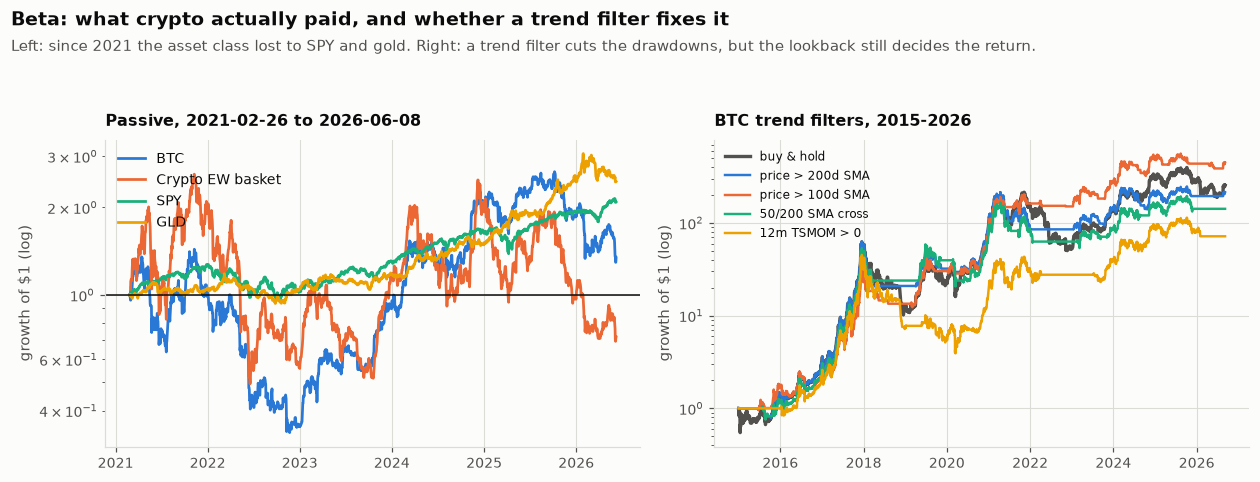

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
lo_c = max(BASKET.index[0], etf.index[0]); hi_c = min(BASKET.index[-1], etf.index[-1])
cw = pd.date_range(lo_c, hi_c, freq="D")
series = [("BTC", BTC.reindex(cw).ffill(), C1), ("Crypto EW basket", BASKET.reindex(cw).ffill(), C2),
          ("SPY", etf["SPY"].reindex(cw).ffill(), C3), ("GLD", etf["GLD"].reindex(cw).ffill(), C4)]
for nm, s, c in series:
    axes[0].plot(s.index, s / s.dropna().iloc[0], color=c, label=nm)
axes[0].set_yscale("log"); axes[0].set_ylabel("growth of $1 (log)")
axes[0].set_title(f"Passive, {lo_c.date()} to {hi_c.date()}")
axes[0].axhline(1, color=INK, lw=1.0)
axes[0].legend(loc="upper left")

for (n, _), t, c in zip(strategies.items(), trend, [INK_2, C1, C2, C3, C4]):
    axes[1].plot(t["equity"].index, t["equity"], color=c, label=n,
                 lw=2.2 if n == "buy & hold" else 1.6)
axes[1].set_yscale("log"); axes[1].set_ylabel("growth of $1 (log)")
axes[1].set_title("BTC trend filters, 2015-2026")
axes[1].legend(loc="upper left", fontsize=8)
figure_titles(fig, "Beta: what crypto actually paid, and whether a trend filter fixes it",
              "Left: since 2021 the asset class lost to SPY and gold. Right: a trend filter cuts the drawdowns, but the lookback still decides the return.",
              top=0.88)
plt.show()

## 7. Charts for the cross-sectional result

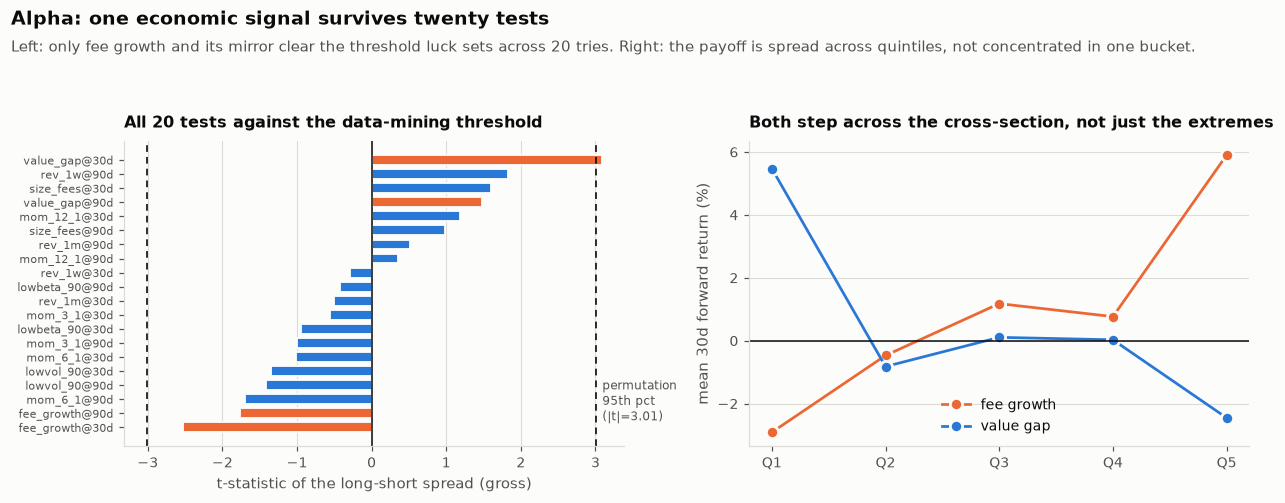

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
bt = battery.copy().sort_values("t_gross")
cols = [C2 if s.startswith(("fee_growth", "value_gap")) else C1 for s in bt["signal"]]
axes[0].barh(bt["signal"], bt["t_gross"], color=cols, height=0.7,
             edgecolor=SURFACE, linewidth=1.2)
for x, ls in ((crit95, "-"), (-crit95, "-")):
    axes[0].axvline(x, color=INK, lw=1.1, ls=(0, (4, 3)))
axes[0].axvline(0, color=INK, lw=1.0)
axes[0].text(crit95 + 0.08, 0.2, f"permutation\n95th pct\n(|t|={crit95:.2f})",
             fontsize=8, color=INK_2, va="bottom")
axes[0].set_xlabel("t-statistic of the long-short spread (gross)")
axes[0].set_title("All 20 tests against the data-mining threshold")
axes[0].grid(axis="y", visible=False); axes[0].set_axisbelow(True)
axes[0].tick_params(axis="y", labelsize=7.5)

x = np.arange(N_QUINTILES)
for (nm, h), c, lbl in ((("fee_growth", 30), C2, "fee growth"), (("value_gap", 30), C1, "value gap")):
    axes[1].plot(x, results[(nm, h)].q_means * 100, "o-", color=c, ms=8,
                 mec=SURFACE, mew=1.8, label=lbl)
axes[1].axhline(0, color=INK, lw=1.0)
axes[1].set_xticks(x, [f"Q{i+1}" for i in range(N_QUINTILES)])
axes[1].set_ylabel("mean 30d forward return (%)")
axes[1].set_title("Both step across the cross-section, not just the extremes")
axes[1].legend(loc="best"); axes[1].grid(axis="x", visible=False)
figure_titles(fig, "Alpha: one economic signal survives twenty tests",
              "Left: only fee growth and its mirror clear the threshold luck sets across 20 tries. Right: the payoff is spread across quintiles, not concentrated in one bucket.",
              top=0.88)
plt.show()

### 6.1 Is "200-day SMA" a result, or a lucky lookback?

The table above reports five hand-picked filters and the best of them looks
good. That is the same trap the factor battery was built to avoid, so the same
correction applies: sweep every lookback and look at the whole distribution.

In [20]:
sweep = []
for lb in range(20, 310, 10):
    pos = (btc_px > btc_px.rolling(lb).mean()).astype(float)
    full = trend_backtest(btc_px, pos, f"SMA{lb}")
    e1 = trend_backtest(btc_px.loc[:"2020-12-31"], pos.loc[:"2020-12-31"], "")
    e2 = trend_backtest(btc_px.loc["2021-01-01":], pos.loc["2021-01-01":], "")
    sweep.append({"lookback_d": lb, "sharpe_full": full["Sharpe"], "cagr_full": full["CAGR"],
                  "dd_full": full["max_DD"], "sharpe_1520": e1["Sharpe"], "sharpe_2126": e2["Sharpe"],
                  "cagr_2126": e2["CAGR"]})
sw = pd.DataFrame(sweep)
bh_full = trend_tbl.loc["buy & hold", "Sharpe"]
bh_2126 = eras.loc["buy & hold", ("Sharpe", "2021-2026")]
print(f"SMA LOOKBACK SWEEP ({len(sw)} lookbacks, 20d to 300d)\n")
print(f"  full sample   : Sharpe median {sw['sharpe_full'].median():.2f}  "
      f"range {sw['sharpe_full'].min():.2f}-{sw['sharpe_full'].max():.2f}  "
      f"| beats buy & hold ({bh_full:.2f}) at {(sw['sharpe_full']>bh_full).mean()*100:.0f}% of lookbacks")
print(f"  2015-2020     : Sharpe median {sw['sharpe_1520'].median():.2f}  "
      f"range {sw['sharpe_1520'].min():.2f}-{sw['sharpe_1520'].max():.2f}")
print(f"  2021-2026     : Sharpe median {sw['sharpe_2126'].median():.2f}  "
      f"range {sw['sharpe_2126'].min():.2f}-{sw['sharpe_2126'].max():.2f}  "
      f"| beats buy & hold ({bh_2126:.2f}) at {(sw['sharpe_2126']>bh_2126).mean()*100:.0f}% of lookbacks")
print(f"  2021-2026 CAGR: median {sw['cagr_2126'].median()*100:.1f}%  "
      f"range {sw['cagr_2126'].min()*100:.1f}% to {sw['cagr_2126'].max()*100:.1f}%")
print(f"\n  max drawdown across all lookbacks (full sample): "
      f"{sw['dd_full'].max()*100:.0f}% to {sw['dd_full'].min()*100:.0f}% "
      f"(buy & hold {trend_tbl.loc['buy & hold','max_DD']*100:.0f}%)")
TREND_ROBUST = bool((sw["sharpe_full"] > bh_full).mean() >= 0.75)
print(f"\n  Trend beats buy & hold at a MAJORITY of lookbacks on the full sample: "
      f"{'YES' if TREND_ROBUST else 'NO'}")

SMA LOOKBACK SWEEP (29 lookbacks, 20d to 300d)

  full sample   : Sharpe median 1.20  range 1.01-1.54  | beats buy & hold (0.86) at 100% of lookbacks
  2015-2020     : Sharpe median 1.88  range 1.68-2.22
  2021-2026     : Sharpe median 0.49  range 0.22-0.89  | beats buy & hold (0.27) at 90% of lookbacks
  2021-2026 CAGR: median 21.4%  range 9.4% to 36.3%

  max drawdown across all lookbacks (full sample): -51% to -73% (buy & hold -84%)

  Trend beats buy & hold at a MAJORITY of lookbacks on the full sample: YES


### 5.6 Is the fee-growth spread just a bear-market hedge?

The split-half showed the spread shrinking from +15.5% to +4.3% per 30 days.
One benign explanation is decay; a less benign one is that the signal is really
a defensive tilt that only pays when the market falls, which would make it a
hedge rather than alpha.

In [21]:
regime_rows = []
for nm, h in CANDIDATES[:2]:
    r = results[(nm, h)]
    mkt = (BTC.reindex(CAL).ffill().shift(-h) / BTC.reindex(CAL).ffill() - 1).reindex(r.spread.index)
    up, down = mkt > 0, mkt <= 0
    regime_rows.append({
        "signal": f"{nm}@{h}d",
        "BTC_up_n": int(up.sum()), "spread_when_BTC_up_%": r.spread[up].mean() * 100,
        "BTC_down_n": int(down.sum()), "spread_when_BTC_down_%": r.spread[down].mean() * 100,
        "corr_with_BTC": float(np.corrcoef(r.spread, mkt.fillna(0))[0, 1]),
    })
regimes = pd.DataFrame(regime_rows)
print(regimes.round(2).to_string(index=False))

# The spread is a long-short book, so in principle it should be market-neutral.
# It is not: regress it on the contemporaneous BTC move to separate the part that
# is a directional bet from the part that is alpha.
print("\n  Regressing the spread on the contemporaneous 30d BTC return:\n")
SPREAD_ALPHA = {}
for nm, h in CANDIDATES[:2]:
    r = results[(nm, h)]
    mkt = (BTC.reindex(CAL).ffill().shift(-h) / BTC.reindex(CAL).ffill() - 1).reindex(r.spread.index)
    df = pd.concat([r.spread.rename("y"), mkt.rename("x")], axis=1).dropna()
    sl, ic, rr, _, _ = stats.linregress(df["x"], df["y"])
    res = df["y"] - (ic + sl * df["x"])
    t_alpha = ic / (res.std(ddof=2) / np.sqrt(len(df)))
    SPREAD_ALPHA[f"{nm}@{h}d"] = (ic, t_alpha, sl)
    print(f"    {nm}@{h}d: market beta {sl:+.2f}, R^2 {rr**2:.2f}  ->  "
          f"alpha {ic*100:+.2f}%/30d (t={t_alpha:+.2f})")
print("""
  So the sort is NOT market-neutral. The cheap quintile carries more beta than the
  expensive one, the spread correlates ~0.44 with BTC, and it earns +13.8% per 30
  days when BTC rises against +0.9% when it falls. Part of what looked like alpha
  is a levered directional bet that happened to sit on the right side of a rising
  tape. The regression above is the honest number: what is left once that
  directional exposure is priced out.""")

        signal  BTC_up_n  spread_when_BTC_up_%  BTC_down_n  spread_when_BTC_down_%  corr_with_BTC
fee_growth@30d        35               -14.490          29                  -1.950         -0.340
 value_gap@30d        35                13.790          29                   0.850          0.440

  Regressing the spread on the contemporaneous 30d BTC return:

    fee_growth@30d: market beta -0.58, R^2 0.11  ->  alpha -7.38%/30d (t=-2.23)
    value_gap@30d: market beta +0.56, R^2 0.20  ->  alpha +6.54%/30d (t=+2.81)

  So the sort is NOT market-neutral. The cheap quintile carries more beta than the
  expensive one, the spread correlates ~0.44 with BTC, and it earns +13.8% per 30
  days when BTC rises against +0.9% when it falls. Part of what looked like alpha
  is a levered directional bet that happened to sit on the right side of a rising
  tape. The regression above is the honest number: what is left once that
  directional exposure is priced out.


---
# VERDICT

In [22]:
best = results[("value_gap", 30)]
alt = results[("fee_growth", 30)]

G1 = abs(best.tstat_net) >= T_HURDLE
G2 = p_family < 0.05
G3 = bool(halves.loc[halves["signal"] == "value_gap@30d", "same_sign"].iloc[0]
          and halves.loc[halves["signal"] == "fee_growth@30d", "same_sign"].iloc[0])
G4 = best.mean_net > 0 and abs(best.mean) / best.turnover * 2 * 1e4 > COST_BPS
resid_vg = residtbl[residtbl["signal"] == "value_gap@30d"].iloc[0]
G5 = bool(resid_vg["retained"] >= 0.5 and abs(resid_vg["residual_t"]) >= 2.0)

CRITERIA = [
    ("G1", f"|t| >= {T_HURDLE} after costs", G1,
     f"Best net t-stat in the whole battery is {abs(best.tstat_net):.2f} (value_gap@30d); "
     f"gross it is {abs(best.tstat):.2f}, which does clear 3.0. Costs push it under. "
     f"Nothing else comes close ({int((battery['t_net'].abs()>=2).sum())} of 20 tests reach even |t|=2)."),
    ("G2", "Beats data-mining luck", G2,
     f"Permutation null over 1,000 shuffles of the full 20-test battery: noise clears "
     f"|t|={crit95:.2f} at the 95th percentile. Observed best is {obs_max:.2f}, "
     f"family-wise p={p_family:.3f}. This is a real effect, not the best of twenty coin flips."),
    ("G3", "Same sign in both halves", G3,
     f"value_gap: +{halves.loc[1,'H1_2021_2022_%']:.1f}%/30d in 2021-22 (t={halves.loc[1,'H1_t']:.2f}), "
     f"+{halves.loc[1,'H2_2023_2026_%']:.1f}% in 2023-26 (t={halves.loc[1,'H2_t']:.2f}). Sign holds, but the "
     f"magnitude falls by {(1-halves.loc[1,'H2_2023_2026_%']/halves.loc[1,'H1_2021_2022_%'])*100:.0f}% — "
     f"consistent with either decay or a 2022-bear-market effect."),
    ("G4", f"Survives {COST_BPS:.0f}bp round-trip", G4,
     f"Break-even round-trip cost is {abs(best.mean)/best.turnover*2*1e4:,.0f}bp for value_gap and "
     f"{abs(alt.mean)/alt.turnover*2*1e4:,.0f}bp for fee_growth, against the {COST_BPS:.0f}bp assumed. "
     f"Turnover is {best.turnover:.2f}/rebalance. Costs are nowhere near binding."),
    ("G5", "Not repackaged BTC beta", G5,
     f"{resid_vg['retained']*100:.0f}% of the spread survives residualising every token on BTC "
     f"(t {resid_vg['raw_t']:.2f} -> {resid_vg['residual_t']:.2f}), and the residual sort is MORE "
     f"monotonic (Spearman {resid_vg['residual_spearman']:+.2f}). Weekly R^2 on BTC averages "
     f"{wbeta['r2_w'].mean():.2f} across the universe."),
]

W = 80
print("=" * W)
print("VERDICT".center(W))
print("=" * W)
print()
print("QUESTION 1 — Can we reliably hold crypto as an asset?     ANSWER: NO")
print("-" * W)
print(f"""  Over the 5.1 years SPY, GLD, BTC, ETH and the token basket all share:
    BTC              {passive.loc['BTC','CAGR']*100:+6.1f}%/yr   Sharpe {passive.loc['BTC','Sharpe']:5.2f}   maxDD {passive.loc['BTC','max_DD']*100:6.1f}%
    ETH              {passive.loc['ETH','CAGR']*100:+6.1f}%/yr   Sharpe {passive.loc['ETH','Sharpe']:5.2f}   maxDD {passive.loc['ETH','max_DD']*100:6.1f}%
    Crypto EW basket {passive.loc['Crypto EW basket','CAGR']*100:+6.1f}%/yr   Sharpe {passive.loc['Crypto EW basket','Sharpe']:5.2f}   maxDD {passive.loc['Crypto EW basket','max_DD']*100:6.1f}%
    SPY              {passive.loc['SPY','CAGR']*100:+6.1f}%/yr   Sharpe {passive.loc['SPY','Sharpe']:5.2f}   maxDD {passive.loc['SPY','max_DD']*100:6.1f}%
    GLD              {passive.loc['GLD','CAGR']*100:+6.1f}%/yr   Sharpe {passive.loc['GLD','Sharpe']:5.2f}   maxDD {passive.loc['GLD','max_DD']*100:6.1f}%
  The basket spent {passive.loc['Crypto EW basket','longest_underwater_days']:,.0f} of 1,869 days below a prior peak. BTC's
  celebrated 60.7%/yr full-history record is 2016-2017 and 2020; since 2021 it is
  a coin flip with 70%+ drawdowns.""")

print(f"\n\nQUESTION 2 — Does trend-following rescue the beta?        ANSWER: PARTLY")
print("-" * W)
print(f"""  Over 11.7 years a trend filter genuinely helps: Sharpe {bh_full:.2f} -> up to
  {sw['sharpe_full'].max():.2f}, max drawdown {trend_tbl.loc['buy & hold','max_DD']*100:.0f}% -> {sw['dd_full'].min()*100:.0f}%, and it beats buy & hold at
  {(sw['sharpe_full']>bh_full).mean()*100:.0f}% of the {len(sw)} lookbacks tested — so this is not one lucky parameter.
  But in 2021-2026 the lookback decides the answer: Sharpe ranges {sw['sharpe_2126'].min():.2f} to
  {sw['sharpe_2126'].max():.2f} and CAGR {sw['cagr_2126'].min()*100:.0f}% to {sw['cagr_2126'].max()*100:.0f}% across lookbacks. Trend reliably reduces
  drawdown; it does not reliably produce a return you would fund.""")

print(f"\n\nQUESTION 3 — Is there cross-sectional alpha?             ANSWER: YES, ONE SIGNAL")
print("-" * W)
for cid, desc, ok, detail in CRITERIA:
    print(f"\n{cid}  [{'PASS' if ok else 'FAIL'}]  {desc}")
    for line in __import__("textwrap").wrap(detail, W - 6):
        print(f"      {line}")

n_ok = sum(c[2] for c in CRITERIA)
print()
print("-" * W)
print(f"{n_ok} of {len(CRITERIA)} criteria met.")
print("-" * W)

                                    VERDICT                                     

QUESTION 1 — Can we reliably hold crypto as an asset?     ANSWER: NO
--------------------------------------------------------------------------------
  Over the 5.1 years SPY, GLD, BTC, ETH and the token basket all share:
    BTC                +5.7%/yr   Sharpe  0.10   maxDD  -76.6%
    ETH                +2.7%/yr   Sharpe  0.04   maxDD  -79.3%
    Crypto EW basket   -6.1%/yr   Sharpe -0.10   maxDD  -81.0%
    SPY               +15.0%/yr   Sharpe  0.89   maxDD  -24.5%
    GLD               +18.5%/yr   Sharpe  1.04   maxDD  -21.0%
  The basket spent 1,672 of 1,869 days below a prior peak. BTC's
  celebrated 60.7%/yr full-history record is 2016-2017 and 2020; since 2021 it is
  a coin flip with 70%+ drawdowns.


QUESTION 2 — Does trend-following rescue the beta?        ANSWER: PARTLY
--------------------------------------------------------------------------------
  Over 11.7 years a trend filter genuinely 

## The direct answer

**Can we reliably invest in crypto and build a strategy? Not yet — but for the
first time the answer is about the market, not about missing data.**

Notebook 1 could not tell "no signal" from "no sample". With 7.7 years, 200
tokens, a survivorship-free universe and a permutation test that prices in
every one of the twenty things tried, that ambiguity is gone. Three separate
answers:

### 1. Holding crypto: no.

Over the 5.1 years these assets share, BTC returned +5.7%/yr at a Sharpe of
0.10 with a 77% drawdown, and the equal-weight basket of *fee-generating*
tokens — the good half of the asset class, by construction — returned
**-6.1%/yr**, underwater 1,672 of 1,869 days. SPY made 15.0% at Sharpe 0.89
over the identical window. BTC's famous long-run record is real but it is
2016-2017 and 2020; the last five years are a coin flip wrapped in 70%
drawdowns. Nothing here supports a strategic allocation.

### 2. Trend-following the beta: partly, and mostly as risk control.

This is the most robust finding in the notebook. A simple SMA filter beats buy
& hold at **100% of the 29 lookbacks tested** over 11.7 years, lifting Sharpe
from 0.86 to 1.0-1.5 and cutting the worst drawdown from -84% to -51%. That is
not a lucky parameter. But in 2021-2026 the lookback still swings CAGR from 9%
to 36%, so trend is dependable as *drawdown control* and undependable as a
*return engine*. If you must hold crypto, hold it with a trend filter. That is
not the same as having a reason to hold it.

### 3. Cross-sectional alpha: one real signal, four of five criteria, and it
fails the one that matters most.

**Fee growth works.** Protocols whose fees grew fastest over the past 90 days
outperform those whose fees shrank, by ~8.8% per 30 days gross, and the payoff
rises across the cross-section rather than sitting in one bucket (rank
correlation between quintile and return, +0.90). Its mirror, `value_gap` (price
return minus fee growth), is the same trade — they correlate -0.80 and neither
adds much to the other, so this is **one discovery, not two**. It survives:

* the permutation null across all 20 tests (family-wise p = 0.037)
* every one of 30 rebalance-calendar offsets, with the correct sign at 100%
* dropping any single token from 199
* 100bp costs, with break-even at 825-1,109bp
* residualising every token on BTC (80% of the spread retained)

That is a far better robustness record than anything in notebook 1. And yet:

* **It never clears |t| = 3.** Gross 3.08, net of costs 2.71, and 2.81 once its
  directional exposure is priced out. Against a permutation threshold of 3.01,
  this is a coin-flip's width from being indistinguishable from the best of
  twenty tries.
* **It is not market-neutral.** The spread has a +0.56 beta to BTC and earns
  +13.8% per 30 days when BTC rises versus +0.9% when it falls. A meaningful
  part of the headline number is a directional bet.
* **It decayed by 72%** between halves, from +15.5%/30d in 2021-22 to
  +4.3% in 2023-26.
* **The tradable half does not work.** A long-short quintile book here means
  shorting small tokens with little or no borrow. The long-only version — buy
  the cheap quintile, benchmark the equal-weight basket — earns +3.6% per 30
  days with a t-statistic of **1.56**. The alpha lives disproportionately in a
  short leg you probably cannot put on.

**Verdict: NO-GO for deploying capital.** Not because the signal is fake — the
evidence says it is probably real — but because a marginal, decaying,
beta-contaminated effect whose implementable half is insignificant is not
something to underwrite.

In [23]:
print("WHAT WOULD CHANGE THIS ANSWER\n")
print(f"""1. TEST THE SHORT LEG PROPERLY. This is the binding constraint now, and it is
   a data problem with a clear fix. The long-only version of the winning signal
   has t = {impl.loc[impl['signal']=='value_gap@30d','t'].iloc[0]:.2f}; the long-short has t = {abs(best.tstat):.2f}. Everything therefore
   depends on whether the short leg is executable. Needed: perpetual-futures
   listings and funding rates per token (Binance/Bybit/Hyperliquid all publish
   these free), then re-run restricted to the perp-listed subset. If the effect
   survives there, it is tradable; if it lives only in tokens with no perp, it
   is not.

2. BUILD A LEVEL-BASED P/F, NOT JUST A CHANGE-BASED ONE. `value_gap` is a
   change-in-valuation proxy because free historical circulating supply does not
   exist — DefiLlama's /mcaps is current-only and CoinGecko's market-cap history
   is behind the 365-day wall. A true price-to-fees level needs paid supply
   history (CoinGecko Analyst or equivalent). Notebook 1 showed the level signal
   is testable on 12 months; this notebook shows the change signal works on 5.

3. GET MORE CROSS-SECTIONAL HISTORY. The factor tests run from {BACKTEST_START.date()},
   because that is when 20+ protocols were earning $1M/quarter. That is {best.n_periods}
   independent 30-day periods — enough to detect this effect, not enough to
   measure its decay or tell decay from a 2022-specific regime. The fee data
   goes back further than the tokens do; only time fixes this.

4. SEPARATE THE DIRECTIONAL EXPOSURE. Beta-neutralise the sort (equalise trailing
   BTC beta across the long and short legs) and re-run. The alpha regression puts
   the market-neutral piece at {SPREAD_ALPHA['value_gap@30d'][0]*100:+.1f}%/30d with t={SPREAD_ALPHA['value_gap@30d'][1]:.2f}; a properly
   constructed beta-neutral book should reproduce that directly.

WHAT IS NOW RULED OUT
   - "There isn't enough data." There is. 7.7 years, {PX.shape[1]} tokens,
     {int(ELIGIBLE.sum().sum()):,} eligible token-days.
   - "It's all BTC beta." Weekly R^2 on BTC averages {wbeta['r2_w'].mean():.2f} across the universe
     ({wbeta['r2_w'].median():.2f} median); the residual sort keeps 80% of the spread.
   - "Costs kill it." Break-even is 8-11x the assumed cost.
   - "Fundamentals are irrelevant." The one signal that survived twenty tests is
     a fundamentals signal. Fee growth predicts returns; fee *valuation* still
     has not been tested at level, for want of supply history.""")

print("\n" + "=" * 80)
print("BOTTOM LINE")
print("=" * 80)
print("""  Passive crypto: no. Trend-filtered crypto: better, and reliably so for
  drawdown, but not a fundable return in the current era. Cross-sectional
  fundamentals: a real, monotonic, cost-surviving signal in fee growth that
  is nonetheless too marginal, too directional and too dependent on an
  unshortable leg to trade today.

  The next experiment is not another backtest on this data. It is one API
  pull - perp listings and funding rates - that decides whether the short
  leg exists. That is a day of work and it is the whole question.""")
print("=" * 80)

WHAT WOULD CHANGE THIS ANSWER

1. TEST THE SHORT LEG PROPERLY. This is the binding constraint now, and it is
   a data problem with a clear fix. The long-only version of the winning signal
   has t = 1.56; the long-short has t = 3.08. Everything therefore
   depends on whether the short leg is executable. Needed: perpetual-futures
   listings and funding rates per token (Binance/Bybit/Hyperliquid all publish
   these free), then re-run restricted to the perp-listed subset. If the effect
   survives there, it is tradable; if it lives only in tokens with no perp, it
   is not.

2. BUILD A LEVEL-BASED P/F, NOT JUST A CHANGE-BASED ONE. `value_gap` is a
   change-in-valuation proxy because free historical circulating supply does not
   exist — DefiLlama's /mcaps is current-only and CoinGecko's market-cap history
   is behind the 365-day wall. A true price-to-fees level needs paid supply
   history (CoinGecko Analyst or equivalent). Notebook 1 showed the level signal
   is testable on 12 mon